# J의료기관 척추 질환 데이터 분석 프로젝트
- 정형 데이터(환자 기본 정보 + 진단/수술 정보) 통계 분석 및 수술실패 예측 모델
- 요추 MRI Middle Slice 영상 기반 추간공 협착 발병 분류 모델 (전통적 ML vs CNN)

**사용 파일**
- `02_Patient_Data.csv` : 환자 기본 정보 (성별, 연령, 신체계측, 통증 지표 등)
- `02_Patient_Diagnosis.csv` : 진단/수술 정보 (직업, 질병력, 수술기법, 수술실패/재발 여부 등)
- `02_Disc_image.csv` : MRI Middle Slice 이미지 경로 및 협착 판독 등급(label)
- `images/` 폴더 : `02_Disc_image.csv`의 `image_path`가 가리키는 실제 MRI 이미지 파일들

> **주의**: 이미지 파트를 실행하려면 이 노트북과 같은 경로(또는 지정한 `DATA_DIR`)에 `images/` 폴더가 실제로 존재해야 합니다.


## 0. 환경 설정 및 라이브러리 임포트

In [1]:
!pip install koreanize-matplotlib

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from scipy import stats

# # 한글 폰트 설정 (환경에 맞게 폰트명 수정, 없으면 주석 처리)
# try:
#     mpl.rc('font', family='Malgun Gothic')  # Windows
#     # mpl.rc('font', family='AppleGothic')  # macOS
#     mpl.rcParams['axes.unicode_minus'] = False
# except Exception:
#     pass

# sns.set(style='whitegrid')

import koreanize_matplotlib

# 데이터 경로
drive.mount('/content/drive', force_remount=True)
DATA_DIR = '/content/drive/MyDrive/ai 헬스케어 7기/의료 이미지 분석을 위한 컴퓨터 비전(CV)/02_Herniated_Disc_Data/'
IMG_DIR = os.path.join(DATA_DIR, 'images')

RANDOM_STATE = 42


Mounted at /content/drive


In [3]:
patient = pd.read_csv(os.path.join(DATA_DIR, '02_Patient_Data.csv'), index_col=0)
diag = pd.read_csv(os.path.join(DATA_DIR, '02_Patient_Diagnosis.csv'), index_col=0)
disc_img = pd.read_csv(os.path.join(DATA_DIR, '02_Disc_image.csv'), index_col=0)

print('Patient_Data:', patient.shape)
print('Patient_Diagnosis:', diag.shape)
print('Disc_image:', disc_img.shape)

patient.head()


Patient_Data: (216, 11)
Patient_Diagnosis: (216, 26)
Disc_image: (469, 10)


,환자ID,성별,연령,체중,신장,Large Lymphocyte,Location of herniation,ODI,헤모글로빈수치,환자통증정도,통증기간(월)
0,1533PT,2,NaN,88.0,160,33.4,4,NaN,12.90,7,60.0
1,611PT,1,67.0,109.0,186,9.5,3,43.0,16.32,10,1.0
2,1389PT,1,61.0,70.0,165,30.6,2,40.0,14.70,8,1.0
3,977PT,2,69.0,80.0,172,19.8,4,NaN,10.60,7,2.0
4,1744PT,2,56.0,80.0,158,41.0,3,NaN,14.80,7,120.0


In [4]:
diag.head()


,환자ID,혈액형,직업,가족력,간질성폐질환,고혈압여부,과거수술횟수,당뇨여부,말초동맥질환여부,빈혈여부,...,혈전합병증여부,흡연여부,입원기간,입원일,퇴원일,수술기법,수술시간,수술실패여부,재발여부,수술일
0,1533PT,RH+A,주부,0.0,0,0,0,0,0,0,...,0,0,1,2016-12-16,2016-12-17,TELD,70.0,0,1,2016-12-16
1,611PT,RH+B,NaN,0.0,0,0,0,0,0,0,...,0,0,2,2021-10-11,2021-10-13,TELD,88.0,0,1,2021-10-11
2,1389PT,RH+A,무직,0.0,0,0,0,0,0,0,...,0,0,3,2014-10-23,2014-10-25,TELD,90.0,0,0,2014-10-24
3,977PT,RH+A,주부,0.0,0,1,0,0,0,1,...,0,0,1,2018-03-15,2018-03-17,TELD,45.0,0,0,2018-03-16
4,1744PT,RH+B,교사,NaN,0,0,1,0,0,0,...,0,0,2,2014-01-16,2014-01-18,TELD,NaN,0,0,2014-01-15


In [5]:
disc_img.head()


,case_id,환자ID,image_path,label,label_3class,fs_grade_max,fs_grade_left_max,fs_grade_right_max,affected_levels,n_abnormal_foramina
0,1,1533PT,images/0001_IM000006.png,1,severe,3.0,1.0,3.0,L3-L4|L4-L5,3.0
1,3,611PT,images/0003_IM000006.png,1,severe,3.0,1.0,3.0,L2-L3|L4-L5|L5-S1,3.0
2,4,1389PT,images/0004_IM000006.png,1,severe,3.0,2.0,3.0,L1-L2|L2-L3|L3-L4|L4-L5,6.0
3,5,977PT,images/0005_IM000006.png,1,severe,3.0,3.0,3.0,L1-L2|L2-L3|L3-L4,5.0
4,6,1744PT,images/0006_IM000006.png,1,severe,3.0,1.0,3.0,L3-L4|L4-L5|L5-S1,5.0


## 1단계. 환자 기본 정보 + 진단 정보 통합 및 결측치 보정

`환자ID`를 기준으로 `02_Patient_Data`와 `02_Patient_Diagnosis`를 통합하고, 분석에 필요한 결측치를 보정합니다.


In [6]:
df = pd.merge(patient, diag, on='환자ID', how='inner')
print(df.shape)
df.isna().sum()


(216, 36)


,0
환자ID,0
성별,0
연령,4
체중,0
신장,0
Large Lymphocyte,0
Location of herniation,0
ODI,184
헤모글로빈수치,1
환자통증정도,0


In [7]:
# 결측치 확인 및 처리 전략
# - 연령: 중앙값 대체
# - ODI: 결측 비율이 매우 높음(184/216) -> 분석 참고용으로만 사용, 모델링 변수에서는 제외 검토
# - 헤모글로빈수치: 중앙값 대체
# - 직업: '미상' 범주로 대체 (결측 자체가 정보일 수 있음)
# - 가족력: 최빈값(0) 대체
# - 수술기법/수술시간: 최빈값/중앙값 대체

df['연령'] = df['연령'].fillna(df['연령'].median())
df['헤모글로빈수치'] = df['헤모글로빈수치'].fillna(df['헤모글로빈수치'].median())
df['직업'] = df['직업'].fillna('미상')
df['가족력'] = df['가족력'].fillna(df['가족력'].mode()[0])
df['수술기법'] = df['수술기법'].fillna(df['수술기법'].mode()[0])
df['수술시간'] = df['수술시간'].fillna(df['수술시간'].median())

print('결측치 처리 후 -----')
print(df.isna().sum()[df.isna().sum() > 0])


결측치 처리 후 -----
ODI    184
dtype: int64


## 문제 1. 성별에 따른 '통증기간(월)', '헤모글로빈수치' 평균 차이 검정

성별(1=남성, 2=여성) 두 집단 간 평균 차이를 검정합니다. 정규성(Shapiro-Wilk), 등분산성(Levene)을 먼저 확인한 뒤 조건에 맞는 검정(독립표본 t-검정 또는 Mann-Whitney U 검정)을 수행합니다.


In [8]:
def compare_groups(df, group_col, target_col, group_labels={1:'남성', 2:'여성'}):
    g1 = df.loc[df[group_col]==1, target_col].dropna()
    g2 = df.loc[df[group_col]==2, target_col].dropna()

    print(f'=== {target_col} : {group_labels[1]}(n={len(g1)}) vs {group_labels[2]}(n={len(g2)}) ===')
    print(f'{group_labels[1]} 평균: {g1.mean():.3f}, {group_labels[2]} 평균: {g2.mean():.3f}')

    # 정규성 검정
    p_norm1 = stats.shapiro(g1).pvalue
    p_norm2 = stats.shapiro(g2).pvalue
    print(f'Shapiro-Wilk p-value : {group_labels[1]}={p_norm1:.4f}, {group_labels[2]}={p_norm2:.4f}')

    # 등분산성 검정
    p_levene = stats.levene(g1, g2).pvalue
    print(f'Levene 등분산 검정 p-value : {p_levene:.4f}')

    normal = (p_norm1 > 0.05) and (p_norm2 > 0.05)
    equal_var = p_levene > 0.05

    if normal:
        stat, p = stats.ttest_ind(g1, g2, equal_var=equal_var)
        test_name = f"독립표본 t-검정 (등분산={equal_var})"
    else:
        stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        test_name = 'Mann-Whitney U 검정 (비모수)'

    print(f'검정방법: {test_name}')
    print(f'통계량={stat:.4f}, p-value={p:.4f}')
    print('=> 유의수준 0.05 기준,', '통계적으로 유의한 차이가 있음' if p < 0.05 else '통계적으로 유의한 차이가 없음')
    print()
    return test_name, stat, p

compare_groups(df, '성별', '통증기간(월)')
compare_groups(df, '성별', '헤모글로빈수치')


=== 통증기간(월) : 남성(n=96) vs 여성(n=120) ===
남성 평균: 10.878, 여성 평균: 11.854
Shapiro-Wilk p-value : 남성=0.0000, 여성=0.0000
Levene 등분산 검정 p-value : 0.9313
검정방법: Mann-Whitney U 검정 (비모수)
통계량=4195.0000, p-value=0.0004
=> 유의수준 0.05 기준, 통계적으로 유의한 차이가 있음

=== 헤모글로빈수치 : 남성(n=96) vs 여성(n=120) ===
남성 평균: 14.685, 여성 평균: 13.697
Shapiro-Wilk p-value : 남성=0.0003, 여성=0.0001
Levene 등분산 검정 p-value : 0.4535
검정방법: Mann-Whitney U 검정 (비모수)
통계량=8147.5000, p-value=0.0000
=> 유의수준 0.05 기준, 통계적으로 유의한 차이가 있음



('Mann-Whitney U 검정 (비모수)',
 np.float64(8147.5),
 np.float64(1.6892855873240848e-07))

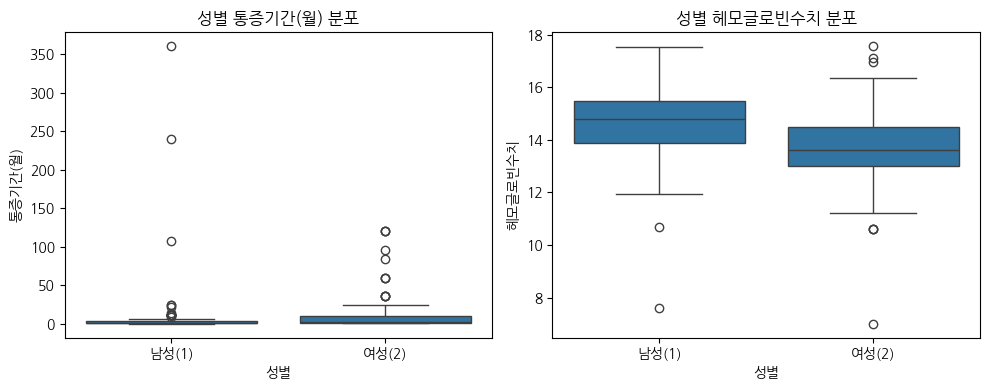

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.boxplot(data=df, x='성별', y='통증기간(월)', ax=axes[0])
axes[0].set_xticklabels(['남성(1)', '여성(2)'])
axes[0].set_title('성별 통증기간(월) 분포')

sns.boxplot(data=df, x='성별', y='헤모글로빈수치', ax=axes[1])
axes[1].set_xticklabels(['남성(1)', '여성(2)'])
axes[1].set_title('성별 헤모글로빈수치 분포')

plt.tight_layout()
plt.show()


## 문제 2. 신장/체중을 이용한 BMI 계산

BMI = 체중(kg) / (신장(m))²


In [10]:
df['BMI'] = df['체중'] / ((df['신장']/100) ** 2)
df[['환자ID', '신장', '체중', 'BMI']].head()


,환자ID,신장,체중,BMI
0,1533PT,160,88.0,34.375000
1,611PT,186,109.0,31.506533
2,1389PT,165,70.0,25.711662
3,977PT,172,80.0,27.041644
4,1744PT,158,80.0,32.046146


count    216.000000
mean      28.141722
std        4.175450
min       17.846520
25%       25.373987
50%       27.649115
75%       31.221304
max       42.039542
Name: BMI, dtype: float64


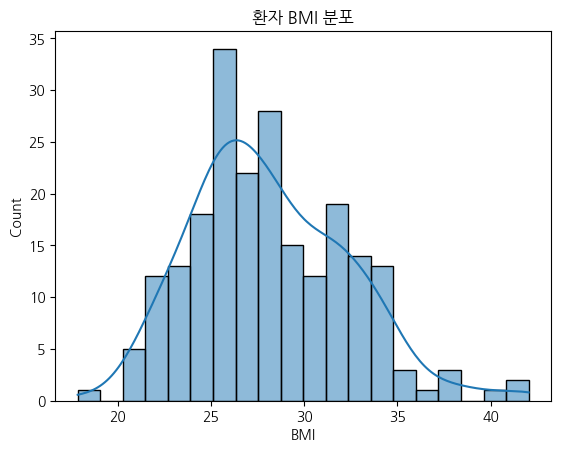

In [11]:
print(df['BMI'].describe())
sns.histplot(df['BMI'], kde=True, bins=20)
plt.title('환자 BMI 분포')
plt.xlabel('BMI')
plt.show()


## 문제 3. 가장 많은 직업 및 해당 직업군의 남/여 성비 (남성=1, 여성=2)


In [12]:
job_counts = df['직업'].value_counts()
print(job_counts)

top_job = job_counts.index[0]
print(f'\n가장 많은 직업: {top_job} ({job_counts.iloc[0]}명)')


직업
미상       60
무직       51
사무직      38
자영업      20
주부       17
교사        6
공무원       6
농업        5
사업가       4
의료직       4
군인        1
운수업       1
학생        1
특수전문직     1
노동직       1
Name: count, dtype: int64

가장 많은 직업: 미상 (60명)


'미상' 직업군의 성별 분포:
남성(1)    30
여성(2)    30
Name: count, dtype: int64
남/여 성비 (남성:여성) = 30:30 = 1.00 : 1


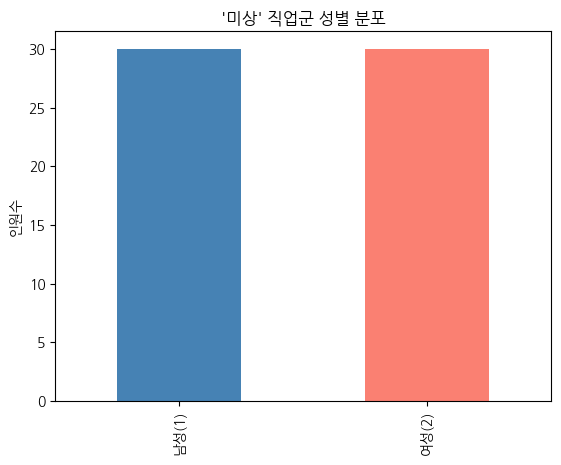

In [13]:
top_job_df = df[df['직업'] == top_job]
gender_ratio = top_job_df['성별'].value_counts().sort_index()
gender_ratio.index = ['남성(1)', '여성(2)']
print(f"'{top_job}' 직업군의 성별 분포:")
print(gender_ratio)

male_n = gender_ratio.get('남성(1)', 0)
female_n = gender_ratio.get('여성(2)', 0)
if female_n > 0:
    print(f'남/여 성비 (남성:여성) = {male_n}:{female_n} = {male_n/female_n:.2f} : 1')

gender_ratio.plot(kind='bar', color=['steelblue','salmon'])
plt.title(f"'{top_job}' 직업군 성별 분포")
plt.ylabel('인원수')
plt.show()


## 문제 4. 수술은 성공했으나 재발한 환자군의 특성

`수술실패여부 == 0` (성공) 이면서 `재발여부 == 1` (재발)인 환자들의 평균 연령, 평균 BMI, 남/여 성비, 직업군 빈도를 확인합니다.


In [14]:
relapse_success = df[(df['수술실패여부'] == 0) & (df['재발여부'] == 1)]
print('해당 환자 수:', len(relapse_success))

print(f"평균 연령: {relapse_success['연령'].mean():.2f}세")
print(f"평균 BMI: {relapse_success['BMI'].mean():.2f}")

gender_ratio_relapse = relapse_success['성별'].value_counts().sort_index()
gender_ratio_relapse.index = ['남성(1)', '여성(2)']
print('\n성별 분포:')
print(gender_ratio_relapse)
m = gender_ratio_relapse.get('남성(1)', 0)
f = gender_ratio_relapse.get('여성(2)', 0)
if f > 0:
    print(f'남/여 성비 = {m}:{f} = {m/f:.2f} : 1')

print('\n직업군 빈도:')
print(relapse_success['직업'].value_counts())


해당 환자 수: 36
평균 연령: 59.11세
평균 BMI: 29.11

성별 분포:
남성(1)    23
여성(2)    13
Name: count, dtype: int64
남/여 성비 = 23:13 = 1.77 : 1

직업군 빈도:
직업
미상     9
무직     8
자영업    6
주부     4
사무직    3
농업     2
교사     2
공무원    1
노동직    1
Name: count, dtype: int64


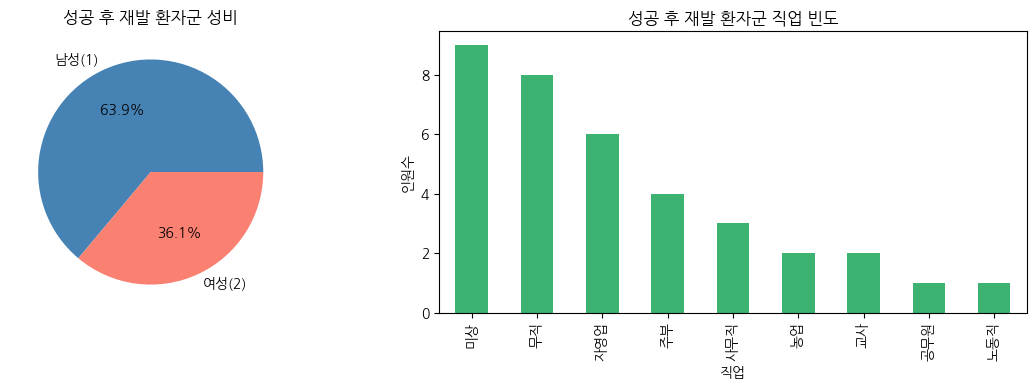

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
gender_ratio_relapse.plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=['steelblue','salmon'])
axes[0].set_ylabel('')
axes[0].set_title('성공 후 재발 환자군 성비')

relapse_success['직업'].value_counts().plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('성공 후 재발 환자군 직업 빈도')
axes[1].set_ylabel('인원수')
plt.tight_layout()
plt.show()


## 문제 5. 통증기간과 통증정도의 상관성 검정

두 변수 모두 연속형/순서형 변수이므로, 정규성 여부에 따라 Pearson 또는 Spearman 상관분석을 수행합니다.


In [16]:
x = df['통증기간(월)']
y = df['환자통증정도']

p_norm_x = stats.shapiro(x).pvalue
p_norm_y = stats.shapiro(y).pvalue
print(f'Shapiro-Wilk p-value: 통증기간={p_norm_x:.4f}, 통증정도={p_norm_y:.4f}')

if p_norm_x > 0.05 and p_norm_y > 0.05:
    corr, p = stats.pearsonr(x, y)
    method = 'Pearson'
else:
    corr, p = stats.spearmanr(x, y)
    method = 'Spearman'

print(f'\n{method} 상관분석 결과')
print(f'상관계수 = {corr:.4f}, p-value = {p:.4f}')
print('=>', '통계적으로 유의한 상관관계가 있음' if p < 0.05 else '통계적으로 유의한 상관관계가 없음')


Shapiro-Wilk p-value: 통증기간=0.0000, 통증정도=0.0000

Spearman 상관분석 결과
상관계수 = 0.1069, p-value = 0.1171
=> 통계적으로 유의한 상관관계가 없음


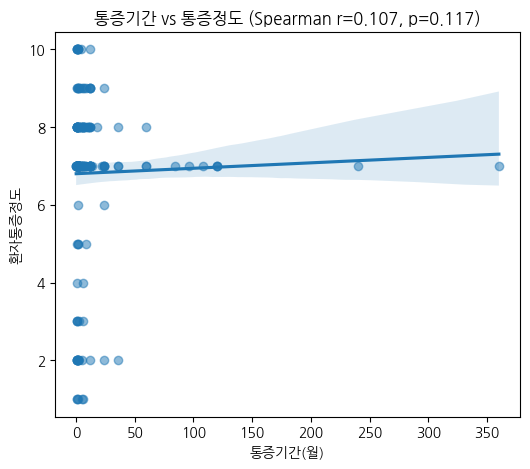

In [17]:
plt.figure(figsize=(6,5))
sns.regplot(x='통증기간(월)', y='환자통증정도', data=df, scatter_kws={'alpha':0.5})
plt.title(f'통증기간 vs 통증정도 ({method} r={corr:.3f}, p={p:.3f})')
plt.show()


## 문제 6. 수술실패여부 분류 모델 (Scikit-Learn)

- **X**: 환자 기본 정보(신체적 정보 + 직업) + 질병력
- **Y**: `수술실패여부`
- 특성공학: 결측 보정, 범주형 인코딩, 파생변수(BMI 등), 표준화
- 클래스 불균형(실패 15명 / 성공 201명) 보정을 위해 `class_weight='balanced'` 적용
- 모델 저장: `02_best_model.sav`


In [18]:
# 사용할 컬럼 정의
physical_cols = ['성별', '연령', '체중', '신장', 'BMI', 'Large Lymphocyte',
                  'Location of herniation', '헤모글로빈수치', '환자통증정도', '통증기간(월)']
job_col = ['직업']
disease_history_cols = ['가족력', '간질성폐질환', '고혈압여부', '과거수술횟수', '당뇨여부',
                         '말초동맥질환여부', '빈혈여부', '스테로이드치료', '신부전여부',
                         '심혈관질환', '암발병여부', '우울증여부', '종양진행여부',
                         '혈전합병증여부', '흡연여부']

feature_cols = physical_cols + job_col + disease_history_cols
target_col = '수술실패여부'

model_df = df[feature_cols + [target_col]].copy()
print(model_df.shape)
model_df.head()


(216, 27)


,성별,연령,체중,신장,BMI,Large Lymphocyte,Location of herniation,헤모글로빈수치,환자통증정도,통증기간(월),...,빈혈여부,스테로이드치료,신부전여부,심혈관질환,암발병여부,우울증여부,종양진행여부,혈전합병증여부,흡연여부,수술실패여부
0,2,60.0,88.0,160,34.375000,33.4,4,12.90,7,60.0,...,0,0,0,0,0,0,0,0,0,0
1,1,67.0,109.0,186,31.506533,9.5,3,16.32,10,1.0,...,0,1,0,0,0,0,0,0,0,0
2,1,61.0,70.0,165,25.711662,30.6,2,14.70,8,1.0,...,0,1,0,0,0,0,0,0,0,0
3,2,69.0,80.0,172,27.041644,19.8,4,10.60,7,2.0,...,1,1,0,0,0,0,0,0,0,0
4,2,56.0,80.0,158,32.046146,41.0,3,14.80,7,120.0,...,0,1,0,0,0,0,0,0,0,0


In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, f1_score)
import joblib

numeric_features = physical_cols + disease_history_cols  # disease history are 0/1 flags, treated as numeric
categorical_features = job_col

X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Train:', X_train.shape, y_train.value_counts().to_dict())
print('Test :', X_test.shape, y_test.value_counts().to_dict())


Train: (172, 26) {0: 160, 1: 12}
Test : (44, 26) {0: 41, 1: 3}


In [20]:
# 전처리 파이프라인 (결측치 처리 + 스케일링 + 원핫인코딩)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


In [21]:
# 여러 모델 비교 (클래스 불균형 -> class_weight='balanced')
candidates = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, clf in candidates.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, 'predict_proba') else pipe.decision_function(X_test)

    f1 = f1_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = np.nan

    results[name] = {'model': pipe, 'f1': f1, 'auc': auc}
    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, digits=3))
    print(f'ROC-AUC: {auc:.3f}\n')


--- LogisticRegression ---
              precision    recall  f1-score   support

           0      0.943     0.805     0.868        41
           1      0.111     0.333     0.167         3

    accuracy                          0.773        44
   macro avg      0.527     0.569     0.518        44
weighted avg      0.886     0.773     0.821        44

ROC-AUC: 0.593

--- RandomForest ---
              precision    recall  f1-score   support

           0      0.932     1.000     0.965        41
           1      0.000     0.000     0.000         3

    accuracy                          0.932        44
   macro avg      0.466     0.500     0.482        44
weighted avg      0.868     0.932     0.899        44

ROC-AUC: 0.736

--- GradientBoosting ---
              precision    recall  f1-score   support

           0      0.930     0.976     0.952        41
           1      0.000     0.000     0.000         3

    accuracy                          0.909        44
   macro avg      0.465

In [22]:
# 최적 모델 선정 (F1-score 기준, 동률 시 AUC로 비교)
best_name = max(results, key=lambda k: (results[k]['f1'], results[k]['auc']))
best_model = results[best_name]['model']
print(f'선정된 최적 모델: {best_name}')
print(f"F1-score: {results[best_name]['f1']:.3f}, ROC-AUC: {results[best_name]['auc']:.3f}")


선정된 최적 모델: LogisticRegression
F1-score: 0.167, ROC-AUC: 0.593


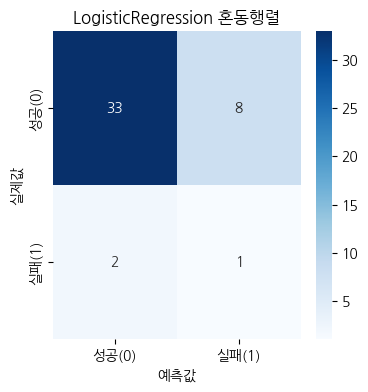

In [23]:
# 혼동행렬 시각화
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['성공(0)','실패(1)'], yticklabels=['성공(0)','실패(1)'])
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.title(f'{best_name} 혼동행렬')
plt.show()


In [24]:
# 모델 저장
joblib.dump(best_model, '02_best_model.sav')
print("'02_best_model.sav' 저장 완료")


'02_best_model.sav' 저장 완료


---
# 2부. MRI 영상 기반 추간공 협착 발병 분류 모델

`02_Disc_image.csv`의 `image_path`(예: `images/0001_IM000006.png`)와 `label`(0=정상, 1=협착)을 이용해
- (1) Scikit-Learn 기반 전통적 머신러닝 모델
- (2) Keras 기반 CNN 모델

두 가지 분류 모델을 각각 구성하고 성능을 비교합니다.


## 이미지-라벨 데이터 확인


In [25]:
print(disc_img['label'].value_counts())
print()
print(disc_img['label_3class'].value_counts())
disc_img[['환자ID','image_path','label','label_3class']].head()


label
1    373
0     96
Name: count, dtype: int64

label_3class
severe      139
mild        124
moderate    110
normal       96
Name: count, dtype: int64


,환자ID,image_path,label,label_3class
0,1533PT,images/0001_IM000006.png,1,severe
1,611PT,images/0003_IM000006.png,1,severe
2,1389PT,images/0004_IM000006.png,1,severe
3,977PT,images/0005_IM000006.png,1,severe
4,1744PT,images/0006_IM000006.png,1,severe


## 2-1. 이미지 로드 및 320x320 리사이즈

`images/` 폴더에 실제 이미지 파일이 존재해야 합니다. 이미지마다 사이즈가 상이하므로 `tf.image.resize`를 이용해 (320, 320)으로 통일합니다.


In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (320, 320)

def load_and_resize_image(rel_path, base_dir=DATA_DIR, target_size=IMG_SIZE):
    """image_path(csv 상의 상대경로)를 받아 로드 후 target_size로 리사이즈한 numpy array 반환"""
    full_path = os.path.join(base_dir, rel_path)
    img = load_img(full_path)                 # PIL Image, 원본 크기 그대로 로드
    arr = img_to_array(img)                    # (H, W, C) numpy array
    arr_resized = tf.image.resize(arr, target_size)  # (320, 320, C) 로 통일
    return arr_resized.numpy()

# 이미지 로드 가능 여부 사전 점검
missing = [p for p in disc_img['image_path'] if not os.path.exists(os.path.join(DATA_DIR, p))]
print(f'전체 이미지 수: {len(disc_img)}, 누락된 이미지 수: {len(missing)}')
if missing:
    print('예시 누락 파일:', missing[:5])


전체 이미지 수: 469, 누락된 이미지 수: 0


In [27]:
# 전체 이미지 로드 (images 폴더가 존재해야 정상 동작)
X_images = []
y_labels = []
failed_paths = []

for _, row in disc_img.iterrows():
    rel_path = row['image_path']
    full_path = os.path.join(DATA_DIR, rel_path)
    if not os.path.exists(full_path):
        failed_paths.append(rel_path)
        continue
    try:
        arr = load_and_resize_image(rel_path)
        X_images.append(arr)
        y_labels.append(row['label'])
    except Exception as e:
        failed_paths.append(rel_path)

X_images = np.array(X_images, dtype=np.float32)
y_labels = np.array(y_labels)

print('로드된 이미지 shape:', X_images.shape)
print('라벨 shape:', y_labels.shape)
print('로드 실패 이미지 수:', len(failed_paths))


로드된 이미지 shape: (469, 320, 320, 3)
라벨 shape: (469,)
로드 실패 이미지 수: 0


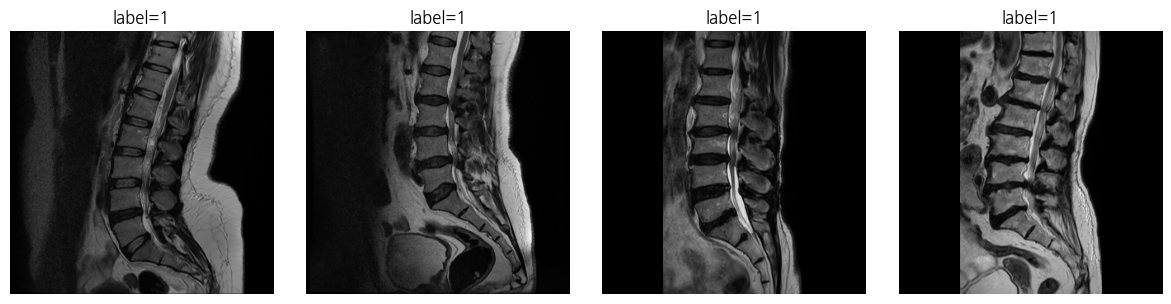

In [28]:
# 픽셀 정규화 (0~1 스케일)
X_images = X_images / 255.0

# 샘플 이미지 확인
fig, axes = plt.subplots(1, 4, figsize=(12,3))
for i, ax in enumerate(axes):
    ax.imshow(X_images[i].astype('float32').squeeze(), cmap='gray' if X_images.shape[-1]==1 else None)
    ax.set_title(f'label={y_labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


In [29]:
from sklearn.model_selection import train_test_split as tts_img

X_train_img, X_test_img, y_train_img, y_test_img = tts_img(
    X_images, y_labels, test_size=0.2, random_state=RANDOM_STATE, stratify=y_labels
)

print('Train:', X_train_img.shape, 'Test:', X_test_img.shape)
print('Train label 분포:', np.bincount(y_train_img.astype(int)))
print('Test label 분포:', np.bincount(y_test_img.astype(int)))


Train: (375, 320, 320, 3) Test: (94, 320, 320, 3)
Train label 분포: [ 77 298]
Test label 분포: [19 75]


## 2-2. Scikit-Learn 기반 전통적 머신러닝 분류 모델

Tensor(4차원: 샘플수, 320, 320, 채널) 데이터를 2차원으로 평탄화(flatten)하여 Scikit-Learn 모델에 입력합니다.
차원이 매우 크므로(320x320xC) PCA로 차원을 축소한 뒤 분류기를 학습합니다.


In [30]:
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_test_flat  = X_test_img.reshape(len(X_test_img),  -1)

print('X_train_flat:', X_train_flat.shape)
print('X_test_flat :', X_test_flat.shape)


X_train_flat: (375, 307200)
X_test_flat : (94, 307200)


In [31]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.svm import SVC as SVC_img
from sklearn.metrics import accuracy_score, f1_score as f1_img, roc_auc_score as auc_img, classification_report as cr_img

# 차원축소 (연산량 감소 + 노이즈 제거 목적)
pca = PCA(n_components=100, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print('PCA 설명 분산 비율 합:', pca.explained_variance_ratio_.sum().round(4))


PCA 설명 분산 비율 합: 0.7847


In [32]:
sklearn_candidates = {
    'RandomForest': RFC(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    'SVM(RBF)': SVC_img(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE)
}

sklearn_results = {}
for name, clf in sklearn_candidates.items():
    clf.fit(X_train_pca, y_train_img)
    pred = clf.predict(X_test_pca)
    proba = clf.predict_proba(X_test_pca)[:, 1]

    acc = accuracy_score(y_test_img, pred)
    f1 = f1_img(y_test_img, pred)
    try:
        auc = auc_img(y_test_img, proba)
    except Exception:
        auc = np.nan

    sklearn_results[name] = {'model': clf, 'acc': acc, 'f1': f1, 'auc': auc}
    print(f'--- {name} ---')
    print(cr_img(y_test_img, pred, digits=3))
    print(f'Accuracy={acc:.3f}, F1={f1:.3f}, AUC={auc:.3f}\n')

best_sklearn_name = max(sklearn_results, key=lambda k: sklearn_results[k]['f1'])
print('Scikit-Learn 최적 모델:', best_sklearn_name)


--- RandomForest ---
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        19
           1      0.798     1.000     0.888        75

    accuracy                          0.798        94
   macro avg      0.399     0.500     0.444        94
weighted avg      0.637     0.798     0.708        94

Accuracy=0.798, F1=0.888, AUC=0.485

--- SVM(RBF) ---
              precision    recall  f1-score   support

           0      0.176     0.158     0.167        19
           1      0.792     0.813     0.803        75

    accuracy                          0.681        94
   macro avg      0.484     0.486     0.485        94
weighted avg      0.668     0.681     0.674        94

Accuracy=0.681, F1=0.803, AUC=0.542

Scikit-Learn 최적 모델: RandomForest


## 2-3. Keras 기반 CNN 분류 모델


In [33]:
from tensorflow.keras import layers, models, callbacks

input_shape = X_train_img.shape[1:]  # (320, 320, C)
print('input_shape:', input_shape)

cnn_model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

cnn_model.summary()


input_shape: (320, 320, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 320, 320, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 320, 320, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [34]:
# 클래스 불균형 보정을 위한 class_weight 계산
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_img)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_img)
class_weight_dict = {int(c): w for c, w in zip(classes, weights)}
print('class_weight:', class_weight_dict)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = cnn_model.fit(
    X_train_img, y_train_img,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)


class_weight: {0: np.float64(2.435064935064935), 1: np.float64(0.6291946308724832)}
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 126s 6s/step - accuracy: 0.5267 - auc: 0.4820 - loss: 0.7396 - val_accuracy: 0.7333 - val_auc: 0.4906 - val_loss: 0.6825
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 144s 7s/step - accuracy: 0.5600 - auc: 0.5352 - loss: 0.7009 - val_accuracy: 0.2133 - val_auc: 0.5011 - val_loss: 0.7456
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 145s 7s/step - accuracy: 0.4967 - auc: 0.5680 - loss: 0.6877 - val_accuracy: 0.2000 - val_auc: 0.5272 - val_loss: 0.9275
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 127s 7s/step - accuracy: 0.4333 - auc: 0.5338 - loss: 0.6914 - val_accuracy: 0.2000 - val_auc: 0.5211 - val_loss: 0.9993
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 123s 6s/step - accuracy: 0.5133 - auc: 0.5222 - loss: 0.7006 - val_accuracy: 0.2000 - val_auc: 0.5278 - val_loss: 1.0784
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 123s 6s/step - accuracy: 0.5800 - auc: 0.5783 - loss: 0.6844 - val_accuracy: 0.2000

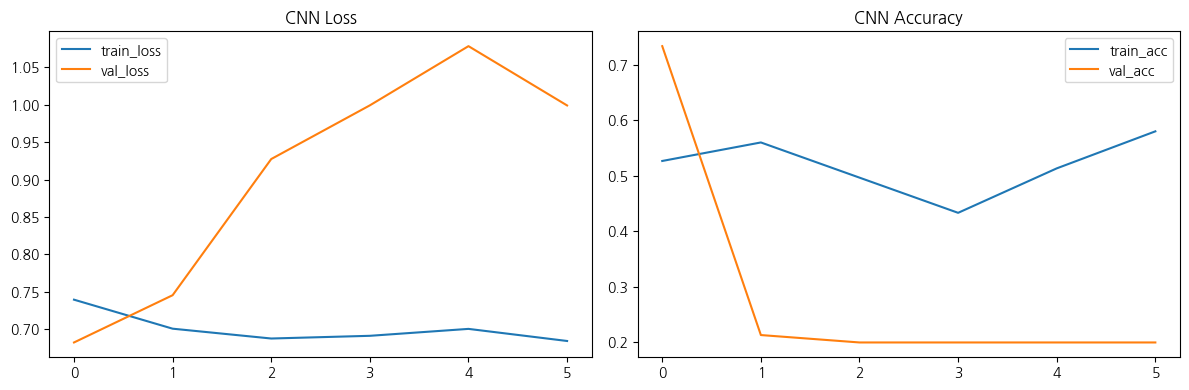

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['loss'], label='train_loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_title('CNN Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train_acc')
axes[1].plot(history.history['val_accuracy'], label='val_acc')
axes[1].set_title('CNN Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()


In [36]:
from sklearn.metrics import accuracy_score as acc_cnn, f1_score as f1_cnn, roc_auc_score as auc_cnn, classification_report as cr_cnn

cnn_proba = cnn_model.predict(X_test_img).ravel()
cnn_pred = (cnn_proba >= 0.5).astype(int)

cnn_acc = acc_cnn(y_test_img, cnn_pred)
cnn_f1 = f1_cnn(y_test_img, cnn_pred)
cnn_auc = auc_cnn(y_test_img, cnn_proba)

print(cr_cnn(y_test_img, cnn_pred, digits=3))
print(f'CNN Accuracy={cnn_acc:.3f}, F1={cnn_f1:.3f}, AUC={cnn_auc:.3f}')


3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step
              precision    recall  f1-score   support

           0      0.375     0.158     0.222        19
           1      0.814     0.933     0.870        75

    accuracy                          0.777        94
   macro avg      0.594     0.546     0.546        94
weighted avg      0.725     0.777     0.739        94

CNN Accuracy=0.777, F1=0.870, AUC=0.639


In [37]:
cnn_model.save('02_cnn_model.h5')
print("'02_cnn_model.h5' 저장 완료")


'02_cnn_model.h5' 저장 완료


## 2-4. Scikit-Learn 모델 vs Keras CNN 모델 성능 비교


In [38]:
comparison = pd.DataFrame({
    'Model': [f'Scikit-Learn ({best_sklearn_name})', 'Keras CNN'],
    'Accuracy': [sklearn_results[best_sklearn_name]['acc'], cnn_acc],
    'F1-score': [sklearn_results[best_sklearn_name]['f1'], cnn_f1],
    'ROC-AUC': [sklearn_results[best_sklearn_name]['auc'], cnn_auc]
})
comparison


,Model,Accuracy,F1-score,ROC-AUC
0,Scikit-Learn (RandomForest),0.797872,0.887574,0.485263
1,Keras CNN,0.776596,0.869565,0.639298


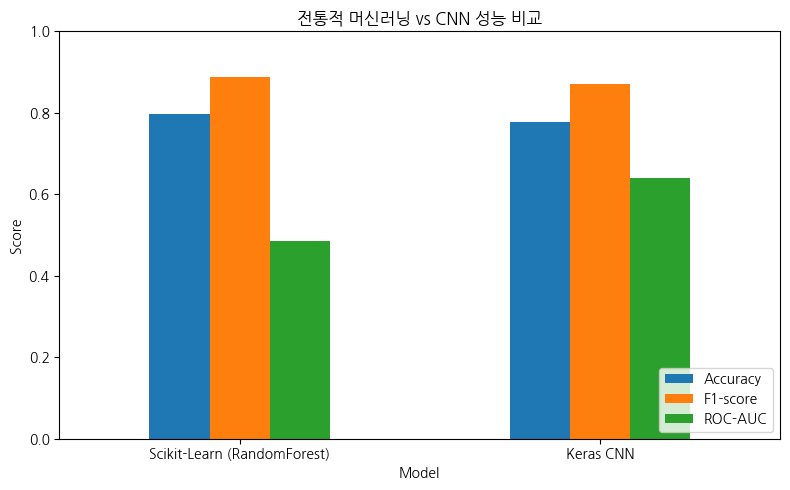

In [39]:
comparison.set_index('Model')[['Accuracy','F1-score','ROC-AUC']].plot(kind='bar', figsize=(8,5))
plt.title('전통적 머신러닝 vs CNN 성능 비교')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 결론 요약

- **정형 데이터 분석**: 성별에 따른 통증기간/헤모글로빈수치 차이, BMI 산출, 직업 분포, 성공 후 재발군 특성, 통증기간-통증정도 상관성을 확인했습니다.
- **수술실패 예측 모델**: 환자 기본정보(신체정보+직업)와 질병력을 이용한 Scikit-Learn 분류모델을 구성했고, 클래스 불균형을 고려하여 `class_weight='balanced'`를 적용, 최적 모델을 `02_best_model.sav`로 저장했습니다.
- **협착 발병 분류 모델**: MRI Middle Slice 이미지를 320x320으로 표준화한 뒤, PCA+전통적 ML(RandomForest/SVM)과 CNN(Conv2D 기반) 두 접근을 비교했습니다. 일반적으로 이미지의 공간적 특징을 보존하는 CNN이 평탄화 기반 전통적 ML보다 우수한 성능을 보이는 경향이 있으나, 실제 우열은 데이터 수/품질에 따라 달라질 수 있으므로 위 비교표의 실제 실행 결과를 기준으로 판단하시기 바랍니다.
